# Customer Churn Prediction using AdaBoost Classifier

## 1.Problem Statement
- Customer churn is like a silent leak in a business bucket 
Companies lose revenue when customers leave, and often they don’t know why or when it will happen.

This project aims to predict customer churn using machine learning (AdaBoost Classifier) by analyzing customer behavior such as:

  - Contract type
  - Support interactions
  - Monthly charges
  - Service usage

The challenge:
Customer behavior is non-linear, noisy, and inconsistent, making it difficult for traditional models to predict churn accurately.

## 2.Objectives
- 🔹 Build a machine learning model to predict customer churn (0 or 1)
- 🔹 Understand how boosting improves weak learners
- 🔹 Handle categorical + numerical features effectively
- 🔹 Compare performance with baseline models 
- 🔹 Apply AdaBoost Classifier to improve accuracy
- 🔹 Visualize model performance (accuracy, confusion matrix)

## 3.Import Libraries

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 4.Load Dataset

In [25]:
df = pd.read_csv("adaboost_churn_dataset_v2.csv")
df.head()

,age,monthly_charge,tenure,support_calls,contract_type,internet_service,payment_method,region,device_type,churn
0,56,1612,19,6,Monthly,DSL,Credit Card,Urban,Mobile,1
1,69,777,70,2,Yearly,NaN,Credit Card,Semi-Urban,Mobile,0
2,46,1554,13,0,Monthly,DSL,UPI,Urban,Mobile,0
3,32,1222,23,3,Yearly,DSL,Cash,Urban,Mobile,1
4,60,719,1,8,Yearly,Fiber,UPI,Urban,Mobile,1


## 5.Basic EDA

churn
0    662
1    538
Name: count, dtype: int64


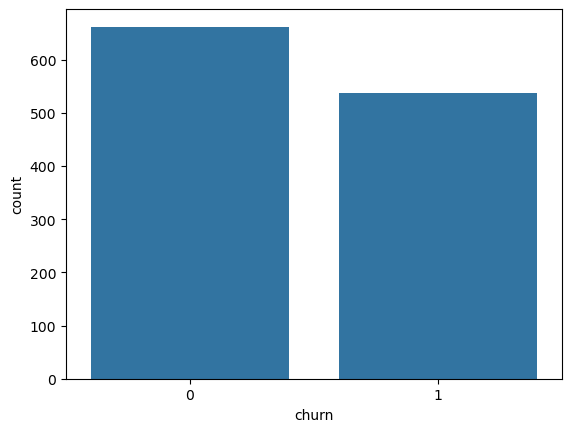

In [26]:
print(df["churn"].value_counts())

sns.countplot(x="churn", data=df)
plt.show()

## 6.Feature Understanding

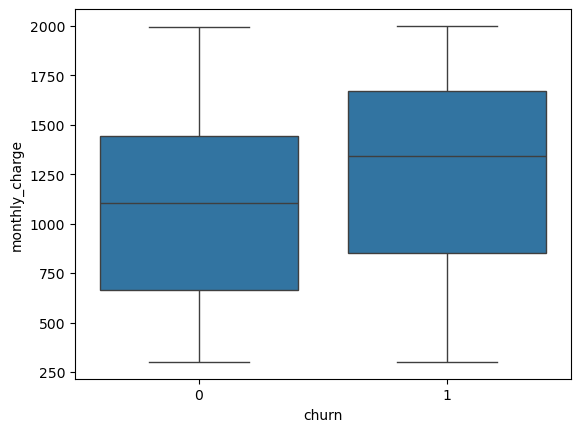

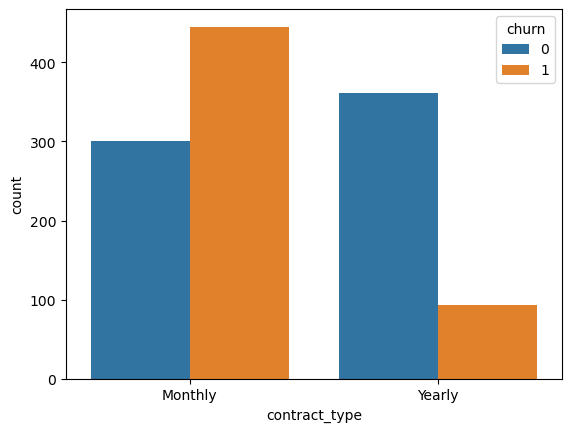

In [27]:
sns.boxplot(x="churn", y="monthly_charge", data=df)
plt.show()

sns.countplot(x="contract_type", hue="churn", data=df)
plt.show()

## 7.Check Missing Values & Handle

In [28]:
df.isnull().sum()

age                   0
monthly_charge        0
tenure                0
support_calls         0
contract_type         0
internet_service    130
payment_method        0
region                0
device_type           0
churn                 0
dtype: int64

## 8.Data Preprocessing

In [29]:
df = pd.get_dummies(df, drop_first=True)
df

,age,monthly_charge,tenure,support_calls,churn,contract_type_Yearly,internet_service_Fiber,payment_method_Cash,payment_method_Credit Card,payment_method_UPI,region_Semi-Urban,region_Urban,device_type_Mobile,device_type_Tablet
0,56,1612,19,6,1,False,False,False,True,False,False,True,True,False
1,69,777,70,2,0,True,False,False,True,False,True,False,True,False
2,46,1554,13,0,0,False,False,False,False,True,False,True,True,False
3,32,1222,23,3,1,True,False,True,False,False,False,True,True,False
4,60,719,1,8,1,True,True,False,False,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,59,1704,35,3,0,False,False,True,False,False,True,False,True,False
1196,69,1425,19,3,1,False,True,True,False,False,False,False,False,True
1197,32,793,8,6,1,True,False,False,False,True,True,False,True,False
1198,64,1967,26,6,1,False,False,False,False,False,False,True,True,False


## 9.Model Building

## i) Seperate Target & Feature

In [30]:
X = df.drop("churn", axis=1)
y = df["churn"]

## ii) Split The Dataset

In [31]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

## iii) Train AdaBoost Model

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

model = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import AdaBoostClassifier

# base_model = DecisionTreeClassifier(max_depth=2)

# model = AdaBoostClassifier(
#     estimator=base_model,
#     n_estimators=100,
#     learning_rate=1.0
# )

# model.fit(X_train, y_train)

AdaBoostClassifier(random_state=42)

## 10.Predictions

In [33]:
y_pred = model.predict(X_test)

## 11.Model Evaluation

Accuracy: 0.8791666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.88      0.89       128
           1       0.86      0.88      0.87       112

    accuracy                           0.88       240
   macro avg       0.88      0.88      0.88       240
weighted avg       0.88      0.88      0.88       240



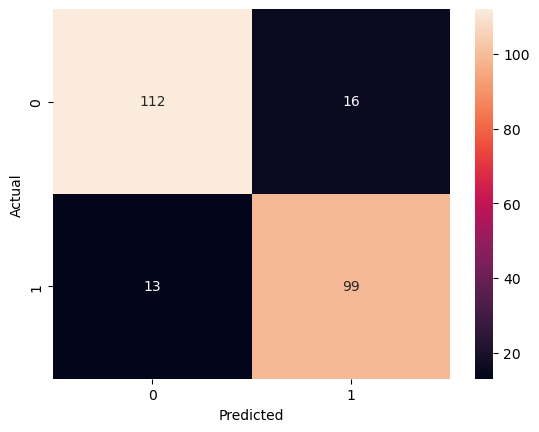

In [34]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 12.Compare with Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=1)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree Accuracy: 0.725
AdaBoost Accuracy: 0.8791666666666667


## 13.Hyperparameter Tuning

In [36]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.5, 1.0, 1.5]
}

grid = GridSearchCV(AdaBoostClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.5, 'n_estimators': 50}


## 14.Conclusion 

The AdaBoost model significantly outperformed the standalone Decision Tree, improving accuracy from 72% to 87%. This demonstrates the effectiveness of boosting in enhancing weak learners by focusing on misclassified samples and iteratively reducing errors.

The model achieved balanced precision and recall for both churn and non-churn classes, making it reliable for real-world applications. With a high recall for churn prediction, the model is particularly useful for identifying customers at risk, enabling businesses to take proactive retention measures.

Overall, this project highlights the practical importance of ensemble learning techniques in solving complex classification problems.